### 梯度下降【模拟】【伪代码】

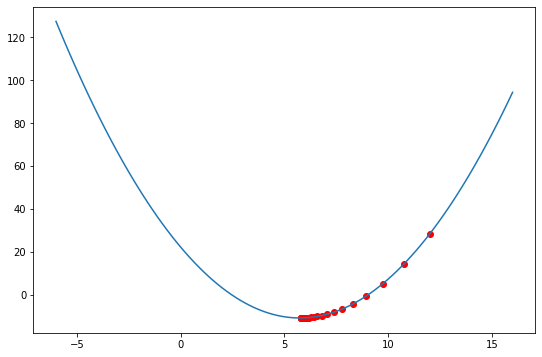

In [7]:
import numpy as np
import matplotlib.pyplot as plt
f = lambda x : (x - 3.5)**2 - 4.5*x + 10 # 一元二次
# 导函数 ，梯度
def g(x):
    return 2*(x - 3.5) - 4.5
eta = 0.1 # 学习率，道士下山，步幅
# 最优解，x = 5.75
theta = 12 # 随机猜
thetas = [theta]

last_theta = theta + 0.1 #记录一下，上一次权重多少 
while True:
    # 1、根据自变量的精确度来判断
#     if np.abs(last_theta - theta) < 0.001:# 精确度，满足一定误差
#         break
    # 2、根据因变量判断
    if np.abs(f(last_theta) - f(theta)) < 0.001:
        break
    # 3、根据损失函数，来判断
    # 最小二乘法的精确都，来作为判断条件
    last_theta = theta # 当前的theta赋值给了上一步的last_theta
    theta = theta - eta * g(theta) # 更新,又走了一步【新的】
    thetas.append(theta)
    
# 可视化了
plt.figure(figsize=(9,6))
x = np.linspace(-6,16,100)
y = f(x)
plt.plot(x,y)

# 梯度下降，散点图，绘制
thetas = np.array(thetas) # 数据没变，只是转换成立列表
plt.scatter(thetas,f(thetas),color = 'red')

In [8]:
len(thetas)

24

### 批量梯度下降

#### 一元一次线性回归

执行多少次111退出!
真是的斜率和截距是：
 5 7
BGD梯度下降结果是：
 [[5.00821298]
 [7.10345165]]


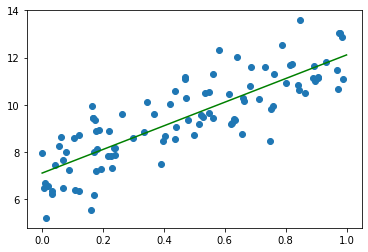

In [47]:
import numpy as np

# 1、 创建数据【事先知道答案，计算机，不知道，验证，梯度下降，破案】
X = np.random.rand(100,1)
# 真实答案
w,b = np.random.randint(1,10,size = 2) # 斜率和截距
# 目标值
y = w * X + b + np.random.randn(100,1) # 加噪声


# 2、截距b相当于w_0,所有的值，都是1
X = np.c_[X,np.ones(shape = (100,1))] # c_默认就是列合并

# 3、训练次数
epoches = 20000

# 4、定义一个函数，调整学习率
t0,t1 = 5,1000
def learning_rate_schedule(t):
    return t0/(t + t1)

# 5、初始化w0、w1、……、wn
theta = np.random.randn(2,1) # w,b


# 6、for循环操作
# 条件判断，是否收敛
loss = 0 # 损失函数的值
loss_last = loss + 1
for i in range(epoches):
    
    if np.abs(loss - loss_last) < 0.0001:
        print('执行多少次%d退出!' % (i))
        break
    # 计算梯度
    g = X.T.dot(X.dot(theta) - y)
    # 更新学习率
    learning_rate = learning_rate_schedule(i)
    theta = theta - learning_rate * g
    loss_last = loss
    loss = ((X.dot(theta) - y)**2).sum() # 最小二乘法
    
print('真是的斜率和截距是：\n',w,b)
print('BGD梯度下降结果是：\n',theta)

plt.scatter(X[:,0],y)
x = np.linspace(0,1,100)
y = x * theta[0,0] + theta[1,0]
plt.plot(x,y,color = 'green')

In [48]:
111 * 100

11100

#### 多元一次线性回归

In [36]:
import numpy as np

# 1、 创建数据【事先知道答案，计算机，不知道，验证，梯度下降，破案】
X = np.random.rand(100,3)
# 真实答案
w = np.random.randint(1,10,size = (3,1)) # 斜率和截距
b = np.random.randint(1,10,size =1)
# 目标值
y = X.dot(w) + b + np.random.randn(100,1) # 加噪声


# 2、截距b相当于w_0,所有的值，都是1
X = np.c_[X,np.ones(shape = (100,1))] # c_默认就是列合并

# 3、训练次数
epoches = 20000

# 4、定义一个函数，调整学习率
t0,t1 = 5,1000
def learning_rate_schedule(t):
    return t0/(t + t1)

# 5、初始化w0、w1、……、wn
theta = np.random.randn(4,1) # w,b

# 6、for循环操作
# 条件判断，是否收敛
loss = 0 # 损失函数的值
loss_last = loss + 1
for i in range(epoches):
    
    if np.abs(loss - loss_last) < 0.00001:
        print('执行多少次%d退出!' % (i))
        break
    # 计算梯度
    g = X.T.dot(X.dot(theta) - y)
    # 更新学习率
    learning_rate = learning_rate_schedule(i)
    theta = theta - learning_rate * g
    loss_last = loss
    loss = ((X.dot(theta) - y)**2).sum() # 最小二乘法
    
print('真是的斜率和截距是：\n',w,b)
print('BGD梯度下降结果是：\n',theta)

执行多少次366退出!
真是的斜率和截距是：
 [[9]
 [4]
 [6]] [3]
BGD梯度下降结果是：
 [[9.16819802]
 [4.1672272 ]
 [6.00179445]
 [2.69175477]]


In [40]:
from sklearn.metrics import mean_squared_error,r2_score

In [39]:
mean_squared_error(X.dot(theta) ,y)

1.1002195379679691

In [41]:
r2_score(X.dot(theta) ,y) # 负数 ~ 1

0.8956131375117002

### SGD随机梯度下降

#### 一元一次线性回归

In [46]:
import numpy as np

# 1、创建数据集X，y
X = 2*np.random.rand(100, 1)
w,b = np.random.randint(1,10,size = 2)
y = w * X + b + np.random.randn(100, 1)

# 2、使用偏置项x_0 = 1，更新X
X = np.c_[X, np.ones((100, 1))]

# 3、创建超参数轮次、样本数量
epochs = 10000

# 4、定义一个函数来调整学习率
t0, t1 = 5, 500
def learning_rate_schedule(t):
    return t0/(t+t1)

# 5、初始化 W0...Wn，标准正太分布创建W
θ = np.random.randn(2, 1)

# 6、多次for循环实现梯度下降，最终结果收敛
# 条件判断，是否收敛
loss = 0 # 损失函数的值
loss_last = loss + 1
for epoch in range(epochs):
    if np.abs(loss - loss_last) < 0.00001:
        print('执行多少次%d退出!' % (i))
        break
    # 在双层for循环之间，每个轮次开始分批次迭代之前打乱数据索引顺序
    index = np.random.randint(0,100,size = 1)[0]
    X_i = X[[index]] # 取出样本
    y_i = y[[index]]
    g = X_i.T.dot(X_i.dot(θ)-y_i)
    learning_rate = learning_rate_schedule(epoch)
    θ = θ - learning_rate * g
    
    loss_last = loss
    loss = ((X.dot(θ) - y)**2).sum() # 最小二乘法
print('真实斜率和截距是：',w,b)
print('梯度下降计算斜率和截距是：',θ)

执行多少次366退出!
真实斜率和截距是： 2 8
梯度下降计算斜率和截距是： [[2.52866524]
 [7.41580951]]


#### 多元一次线性回归

In [51]:
import numpy as np

# 1、创建数据集X，y
X = 2*np.random.rand(100, 5)
w = np.random.randint(1,10,size = (5,1))
b = np.random.randint(1,10,size = 1)
y = X.dot(w)+ b + np.random.randn(100, 1)

# 2、使用偏置项x_0 = 1，更新X
X = np.c_[X, np.ones((100, 1))]

# 3、创建超参数轮次、样本数量
epochs = 10000

# 4、定义一个函数来调整学习率
t0, t1 = 5, 500
def learning_rate_schedule(t):
    return t0/(t+t1)

# 5、初始化 W0...Wn，标准正太分布创建W
θ = np.random.randn(6, 1)

# 6、多次for循环实现梯度下降，最终结果收敛
# 条件判断，是否收敛
loss = 0 # 损失函数的值
loss_last = loss + 1
for epoch in range(epochs):
    if np.abs(loss - loss_last) < 0.0000001:
        print('执行多少次%d退出!' % (i))
        break
    # 在双层for循环之间，每个轮次开始分批次迭代之前打乱数据索引顺序
    index = np.random.randint(0,100,size = 1)[0]
    X_i = X[[index]] # 取出样本
    y_i = y[[index]]
    g = X_i.T.dot(X_i.dot(θ)-y_i)
    learning_rate = learning_rate_schedule(epoch)
    θ = θ - learning_rate * g
    
    loss_last = loss
    loss = ((X.dot(θ) - y)**2).sum() # 最小二乘法
print('真实斜率和截距是：',w,b)
print('梯度下降计算斜率和截距是：',θ)

真实斜率和截距是： [[4]
 [3]
 [4]
 [1]
 [7]] [9]
梯度下降计算斜率和截距是： [[4.45749799]
 [2.99951171]
 [4.4886165 ]
 [1.40832909]
 [7.26153042]
 [7.38982739]]
